In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
customers=pd.read_csv(f"C:/Users/Akshay/Downloads/customers_master.csv")
transactions=pd.read_csv(f"C:/Users/Akshay/Downloads/transactions_data.csv")

print("Customers shape:", customers.shape)
print("Transactions shape:", transactions.shape)

Customers shape: (2000, 6)
Transactions shape: (25000, 6)


In [12]:
customers.head(), transactions.head()

(  customer_id  gender  age       city customer_segment signup_date
 0  CUST100000    Male   32  Bengaluru        Low Value  2024-04-03
 1  CUST100001  Female   36     Mumbai       High Value  2023-12-02
 2  CUST100002    Male   44  Bengaluru        Mid Value  2024-10-15
 3  CUST100003    Male   39  Hyderabad       High Value  2024-12-03
 4  CUST100004    Male   28  Bengaluru        Mid Value  2022-05-08,
   transaction_id customer_id transaction_date  transaction_amount  \
 0      TXN500000  CUST100367       2023-11-23              279.36   
 1      TXN500001  CUST100558       2023-07-31             2375.96   
 2      TXN500002  CUST101669       2023-11-05             1872.03   
 3      TXN500003  CUST100107       2023-04-18             5542.35   
 4      TXN500004  CUST100583       2023-06-26              722.12   
 
   payment_mode     channel  
 0  Credit Card  Mobile App  
 1  Net Banking     Website  
 2          UPI  Mobile App  
 3  Credit Card  Mobile App  
 4   Debit Card  Mo

In [13]:
# Missing values
print("Customer nulls:\n", customers.isnull().sum())
print("\nTransaction nulls:\n", transactions.isnull().sum())

# Duplicate checks
print("\nDuplicate customers:", customers.duplicated(subset="customer_id").sum())
print("Duplicate transactions:", transactions.duplicated(subset="transaction_id").sum())


Customer nulls:
 customer_id         0
gender              0
age                 0
city                0
customer_segment    0
signup_date         0
dtype: int64

Transaction nulls:
 transaction_id        0
customer_id           0
transaction_date      0
transaction_amount    0
payment_mode          0
channel               0
dtype: int64

Duplicate customers: 0
Duplicate transactions: 0


In [15]:
customers.info(),transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       2000 non-null   object
 1   gender            2000 non-null   object
 2   age               2000 non-null   int64 
 3   city              2000 non-null   object
 4   customer_segment  2000 non-null   object
 5   signup_date       2000 non-null   object
dtypes: int64(1), object(5)
memory usage: 93.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      25000 non-null  object 
 1   customer_id         25000 non-null  object 
 2   transaction_date    25000 non-null  object 
 3   transaction_amount  25000 non-null  float64
 4   payment_mode        25000 non-null  object 
 5   channel            

(None, None)

In [19]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
customers.info(),transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2000 non-null   object        
 1   gender            2000 non-null   object        
 2   age               2000 non-null   int64         
 3   city              2000 non-null   object        
 4   customer_segment  2000 non-null   object        
 5   signup_date       2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 93.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      25000 non-null  object        
 1   customer_id         25000 non-null  object        
 2   transaction_date    25000 non-null  datetime64[ns]
 3  

(None, None)

In [18]:
#join dataset
data = pd.merge(
    transactions,
    customers,
    on="customer_id",
    how="left"
)

data.shape


(25000, 11)

In [20]:
# Check if any transactions lost customer info
data.isnull().sum()


transaction_id        0
customer_id           0
transaction_date      0
transaction_amount    0
payment_mode          0
channel               0
gender                0
age                   0
city                  0
customer_segment      0
signup_date           0
dtype: int64

In [21]:
data.head()


,transaction_id,customer_id,transaction_date,transaction_amount,payment_mode,channel,gender,age,city,customer_segment,signup_date
0,TXN500000,CUST100367,2023-11-23,279.36,Credit Card,Mobile App,Female,41,Delhi,Mid Value,2024-01-05
1,TXN500001,CUST100558,2023-07-31,2375.96,Net Banking,Website,Female,48,Delhi,Mid Value,2022-09-29
2,TXN500002,CUST101669,2023-11-05,1872.03,UPI,Mobile App,Female,34,Chennai,Low Value,2022-05-05
3,TXN500003,CUST100107,2023-04-18,5542.35,Credit Card,Mobile App,Female,35,Hyderabad,Mid Value,2023-02-05
4,TXN500004,CUST100583,2023-06-26,722.12,Debit Card,Mobile App,Female,34,Chennai,Low Value,2022-11-25


In [22]:
# Aggregate transaction data at customer level
customer_metrics = data.groupby("customer_id").agg(
    total_spend=("transaction_amount", "sum"),              # Total money spent
    transaction_count=("transaction_id", "count"),          # Number of transactions
    avg_transaction_value=("transaction_amount", "mean"),   # Average spend per transaction
    last_transaction_date=("transaction_date", "max")       # Most recent transaction
).reset_index()

customer_metrics.head()


,customer_id,total_spend,transaction_count,avg_transaction_value,last_transaction_date
0,CUST100000,22138.20,14,1581.300000,2024-10-21
1,CUST100001,14591.62,7,2084.517143,2024-12-18
2,CUST100002,13594.58,8,1699.322500,2024-12-03
3,CUST100003,30148.23,12,2512.352500,2024-12-11
4,CUST100004,17905.22,9,1989.468889,2024-03-31


In [24]:
# Defining analysis reference date (latest transaction date)
analysis_date = data["transaction_date"].max()

# Calculate recency in days
customer_metrics["recency_days"] = (
    analysis_date - customer_metrics["last_transaction_date"]
).dt.days

customer_metrics.head()


,customer_id,total_spend,transaction_count,avg_transaction_value,last_transaction_date,recency_days
0,CUST100000,22138.20,14,1581.300000,2024-10-21,71
1,CUST100001,14591.62,7,2084.517143,2024-12-18,13
2,CUST100002,13594.58,8,1699.322500,2024-12-03,28
3,CUST100003,30148.23,12,2512.352500,2024-12-11,20
4,CUST100004,17905.22,9,1989.468889,2024-03-31,275


In [26]:
# Understanding distribution of customer metrics
customer_metrics.describe()


,total_spend,transaction_count,avg_transaction_value,last_transaction_date,recency_days
count,2000.000000,2000.000000,2000.000000,2000,2000.00000
mean,27899.325015,12.500000,2231.538013,2024-10-31 12:05:45.600000,60.49600
min,2870.820000,2.000000,596.685000,2023-10-24 00:00:00,0.00000
25%,20080.147500,10.000000,1782.585389,2024-10-07 00:00:00,17.00000
50%,26722.305000,12.000000,2165.534737,2024-11-19 00:00:00,42.00000
75%,34623.427500,15.000000,2613.434143,2024-12-14 00:00:00,85.00000
max,69687.950000,25.000000,5389.774444,2024-12-31 00:00:00,434.00000
std,11061.960128,3.502732,659.948098,NaN,59.61321


In [27]:
# Defining percentile thresholds based on total spend
spend_q30 = customer_metrics["total_spend"].quantile(0.30)
spend_q75 = customer_metrics["total_spend"].quantile(0.75)

# Function to assign value segment
def value_segment(spend):
    if spend >= spend_q75:
        return "High Value"
    elif spend >= spend_q30:
        return "Mid Value"
    else:
        return "Low Value"

# Applying segmentation logic
customer_metrics["value_segment"] = customer_metrics["total_spend"].apply(value_segment)

# Checking segment distribution
customer_metrics["value_segment"].value_counts(normalize=True) * 100


value_segment
Mid Value     45.0
Low Value     30.0
High Value    25.0
Name: proportion, dtype: float64

In [28]:
# Merge customer value segments into transaction-level data
final_data = pd.merge(
    data,
    customer_metrics[["customer_id", "value_segment"]],
    on="customer_id",
    how="left"
)

final_data.head()


,transaction_id,customer_id,transaction_date,transaction_amount,payment_mode,channel,gender,age,city,customer_segment,signup_date,value_segment
0,TXN500000,CUST100367,2023-11-23,279.36,Credit Card,Mobile App,Female,41,Delhi,Mid Value,2024-01-05,High Value
1,TXN500001,CUST100558,2023-07-31,2375.96,Net Banking,Website,Female,48,Delhi,Mid Value,2022-09-29,High Value
2,TXN500002,CUST101669,2023-11-05,1872.03,UPI,Mobile App,Female,34,Chennai,Low Value,2022-05-05,High Value
3,TXN500003,CUST100107,2023-04-18,5542.35,Credit Card,Mobile App,Female,35,Hyderabad,Mid Value,2023-02-05,Mid Value
4,TXN500004,CUST100583,2023-06-26,722.12,Debit Card,Mobile App,Female,34,Chennai,Low Value,2022-11-25,Mid Value


In [29]:
# Calculate total revenue contribution by segment
final_data.groupby("value_segment")["transaction_amount"].sum().sort_values(ascending=False)


value_segment
Mid Value     24865478.94
High Value    21397446.30
Low Value      9535724.79
Name: transaction_amount, dtype: float64

In [30]:
segment_revenue = final_data.groupby("value_segment")["transaction_amount"].sum()

# Convert to percentage contribution
(segment_revenue / segment_revenue.sum()) * 100


value_segment
High Value    38.347606
Low Value     17.089526
Mid Value     44.562868
Name: transaction_amount, dtype: float64

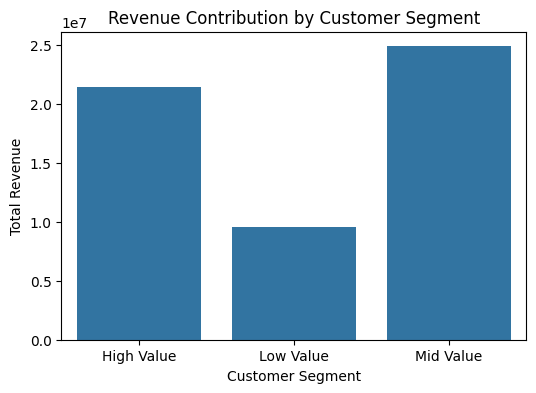

In [31]:
# Visualize revenue contribution by segment
plt.figure(figsize=(6,4))
sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)
plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Total Revenue")
plt.xlabel("Customer Segment")
plt.show()


In [32]:
# Revenue by city
city_revenue = final_data.groupby("city")["transaction_amount"].sum().sort_values(ascending=False)
city_revenue


city
Mumbai       12467726.42
Delhi        11772978.62
Bengaluru     9831669.97
Hyderabad     8448866.17
Pune          8300098.64
Chennai       4977310.21
Name: transaction_amount, dtype: float64

In [33]:
# Average transaction value by city
final_data.groupby("city")["transaction_amount"].mean().sort_values(ascending=False)


city
Bengaluru    2270.069261
Mumbai       2266.447268
Hyderabad    2232.787043
Pune         2218.684480
Chennai      2210.173273
Delhi        2183.820927
Name: transaction_amount, dtype: float64

In [34]:
# Customer count by city
final_data.groupby("city")["customer_id"].nunique().sort_values(ascending=False)


city
Mumbai       442
Delhi        426
Bengaluru    343
Pune         302
Hyderabad    301
Chennai      186
Name: customer_id, dtype: int64

In [35]:
segment_city = final_data.groupby(["city", "value_segment"])["transaction_amount"].sum().reset_index()
segment_city


,city,value_segment,transaction_amount
0,Bengaluru,High Value,4132907.53
1,Bengaluru,Low Value,1589772.49
2,Bengaluru,Mid Value,4108989.95
3,Chennai,High Value,1453198.74
4,Chennai,Low Value,914862.75
5,Chennai,Mid Value,2609248.72
6,Delhi,High Value,4516569.64
7,Delhi,Low Value,2214019.87
8,Delhi,Mid Value,5042389.11
9,Hyderabad,High Value,3103953.93


In [36]:
# Pivot table for clarity
segment_city_pivot = segment_city.pivot(
    index="city",
    columns="value_segment",
    values="transaction_amount"
)

segment_city_pivot


value_segment,High Value,Low Value,Mid Value
city,,,
Bengaluru,4132907.53,1589772.49,4108989.95
Chennai,1453198.74,914862.75,2609248.72
Delhi,4516569.64,2214019.87,5042389.11
Hyderabad,3103953.93,1245958.22,4098954.02
Mumbai,5122401.74,2128148.57,5217176.11
Pune,3068414.72,1442962.89,3788721.03


In [37]:
# Revenue by channel
final_data.groupby("channel")["transaction_amount"].sum()


channel
Mobile App    36290518.44
Website       19508131.59
Name: transaction_amount, dtype: float64

In [38]:
# Average order value by channel
final_data.groupby("channel")["transaction_amount"].mean()


channel
Mobile App    2223.002661
Website       2248.775976
Name: transaction_amount, dtype: float64

In [39]:
# Transaction volume by channel
final_data["channel"].value_counts()


channel
Mobile App    16325
Website        8675
Name: count, dtype: int64

In [40]:
# Revenue by payment mode
final_data.groupby("payment_mode")["transaction_amount"].sum().sort_values(ascending=False)


payment_mode
UPI            19763382.25
Credit Card    13785614.20
Debit Card     11020093.67
Wallet          5670177.40
Net Banking     5559382.51
Name: transaction_amount, dtype: float64

In [41]:
# Avg transaction value by payment mode
final_data.groupby("payment_mode")["transaction_amount"].mean().sort_values(ascending=False)


payment_mode
UPI            2257.640193
Wallet         2250.963636
Debit Card     2248.998708
Net Banking    2198.253266
Credit Card    2188.887615
Name: transaction_amount, dtype: float64

In [43]:
# Create Year-Month column
final_data["year_month"] = final_data["transaction_date"].dt.to_period("M")


In [44]:
# Monthly revenue trend
monthly_revenue = final_data.groupby("year_month")["transaction_amount"].sum()
monthly_revenue


year_month
2023-01    2422774.56
2023-02    2193277.95
2023-03    2357986.08
2023-04    2342930.16
2023-05    2210643.70
2023-06    2258363.17
2023-07    2438246.12
2023-08    2499482.61
2023-09    2405508.07
2023-10    2360029.21
2023-11    2307003.52
2023-12    2370969.46
2024-01    2359105.10
2024-02    2175759.15
2024-03    2221274.40
2024-04    2136075.09
2024-05    2475980.94
2024-06    2525928.32
2024-07    2338815.68
2024-08    2316911.97
2024-09    2293618.41
2024-10    2250820.60
2024-11    2179701.94
2024-12    2357443.82
Freq: M, Name: transaction_amount, dtype: float64

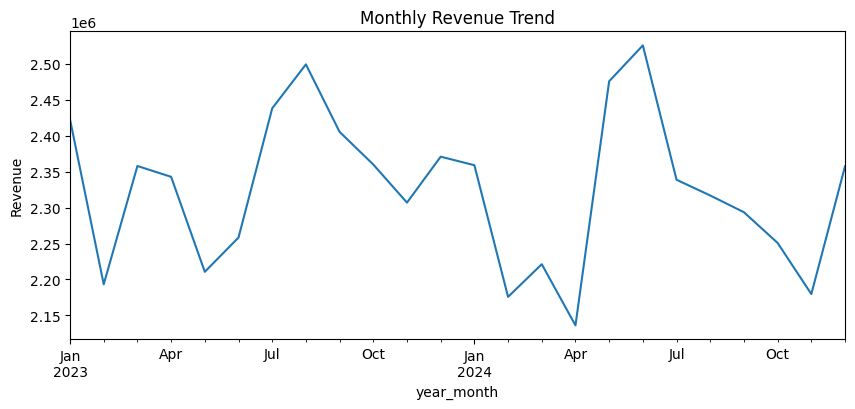

In [48]:
# Plot monthly trend
monthly_revenue.plot(figsize=(10,4), title="Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()


In [47]:
# Revenue contribution by customer
customer_revenue = final_data.groupby("customer_id")["transaction_amount"].sum().sort_values(ascending=False)

# Top 20% customers revenue share
top_20_percent = int(0.2 * len(customer_revenue))

customer_revenue.head(top_20_percent).sum() / customer_revenue.sum() * 100


31.94548427321513

In [53]:
final_data.to_csv("final_customer_analytics_data.csv", index=False)
final_data

,transaction_id,customer_id,transaction_date,transaction_amount,payment_mode,channel,gender,age,city,customer_segment,signup_date,value_segment,year_month
0,TXN500000,CUST100367,2023-11-23,279.36,Credit Card,Mobile App,Female,41,Delhi,Mid Value,2024-01-05,High Value,2023-11
1,TXN500001,CUST100558,2023-07-31,2375.96,Net Banking,Website,Female,48,Delhi,Mid Value,2022-09-29,High Value,2023-07
2,TXN500002,CUST101669,2023-11-05,1872.03,UPI,Mobile App,Female,34,Chennai,Low Value,2022-05-05,High Value,2023-11
3,TXN500003,CUST100107,2023-04-18,5542.35,Credit Card,Mobile App,Female,35,Hyderabad,Mid Value,2023-02-05,Mid Value,2023-04
4,TXN500004,CUST100583,2023-06-26,722.12,Debit Card,Mobile App,Female,34,Chennai,Low Value,2022-11-25,Mid Value,2023-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,TXN524995,CUST101432,2024-09-28,2943.10,Net Banking,Mobile App,Female,57,Chennai,Mid Value,2022-08-05,Mid Value,2024-09
24996,TXN524996,CUST101782,2023-08-19,2224.58,UPI,Website,Female,39,Mumbai,Mid Value,2022-09-22,High Value,2023-08
24997,TXN524997,CUST100070,2023-11-07,3966.25,UPI,Mobile App,Female,62,Pune,Low Value,2022-03-16,Mid Value,2023-11
24998,TXN524998,CUST101844,2023-01-03,4696.54,Credit Card,Mobile App,Female,56,Bengaluru,Low Value,2023-12-18,High Value,2023-01


In [56]:
import os
os.listdir()

['-1.14-windows.xml',
 '.accessibility.properties',
 '.anaconda',
 '.android',
 '.antigravity',
 '.bash_history',
 '.cache',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.cursor',
 '.dotnet',
 '.emulator_console_auth_token',
 '.expo',
 '.gemini',
 '.gitconfig',
 '.gk',
 '.gradle',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.lesshst',
 '.matplotlib',
 '.node_repl_history',
 '.nuget',
 '.packettracer',
 '.redhat',
 '.spss',
 '.templateengine',
 '.virtual_documents',
 '.vscode',
 'Airbnbproject.ipynb',
 'akshay.cpp',
 'anaconda3',
 'AndroidStudioProjects',
 'AppData',
 'Application Data',
 'Assignemt1.ipynb',
 'Assignment1nlp.ipynb',
 'Assignment2.ipynb',
 'bus',
 'c',
 'cd',
 'Cisco Packet Tracer 6.2sv',
 'Contacts',
 'Cookies',
 'Customer_Analytics_capstone.ipynb',
 'Customer_Data.ipynb',
 'customer_patterns.ipynb',
 'Delta',
 'Desktop',
 'Documents',
 'Downloads',
 'edusage',
 'Favorites',
 'finaldeeplearning.ipynb',
 'final_customer_analytics_dat